### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [1]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env
import src.utils.exps_utils as exps
import numpy as np

seed = 42
max_iterations = 10000

env_id = "convex_optimization_env/ConvexOptimization-v1"

available_dims = [2, 5, 10, 100]

base_env_kwargs = {
    
}

### 1. Convergence on [2, 5, 10, 100] vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

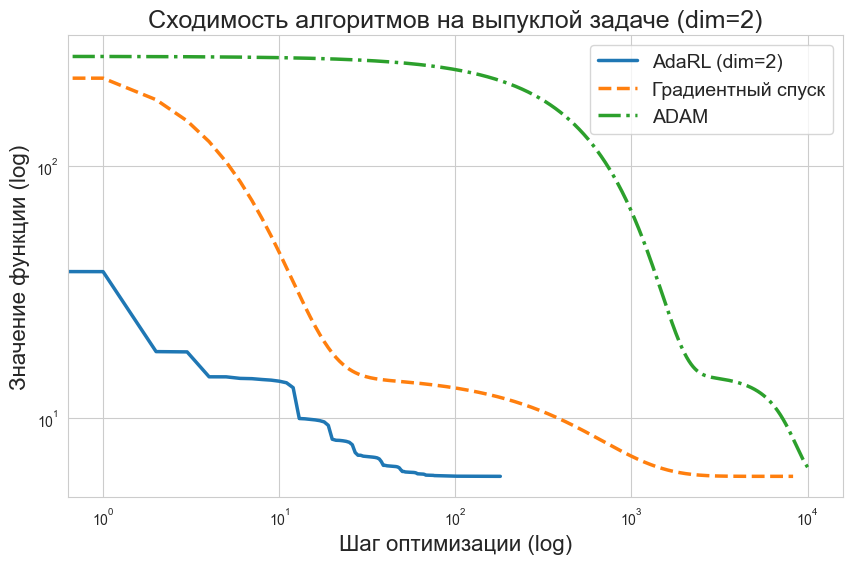

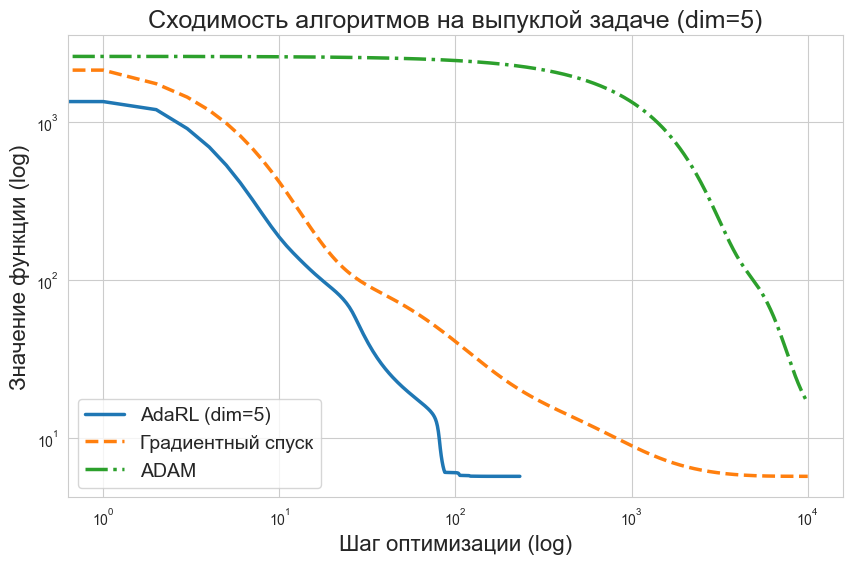

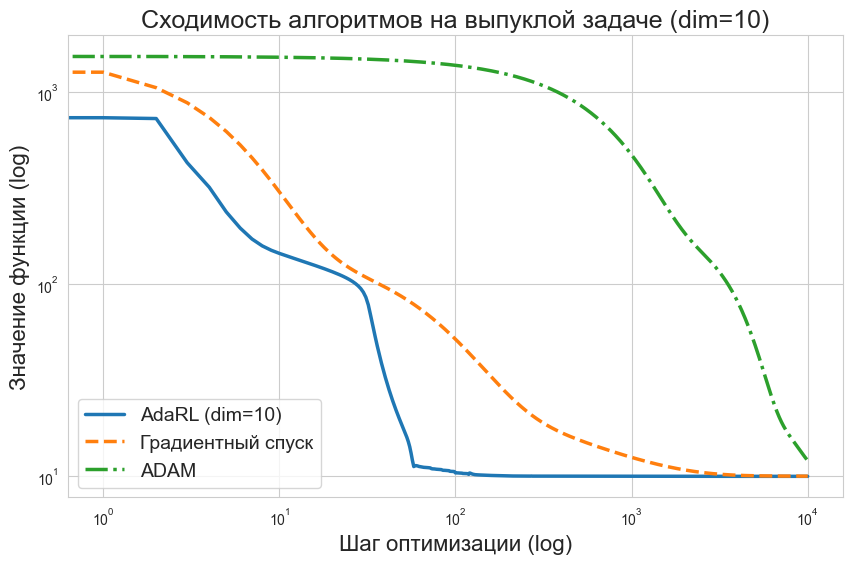

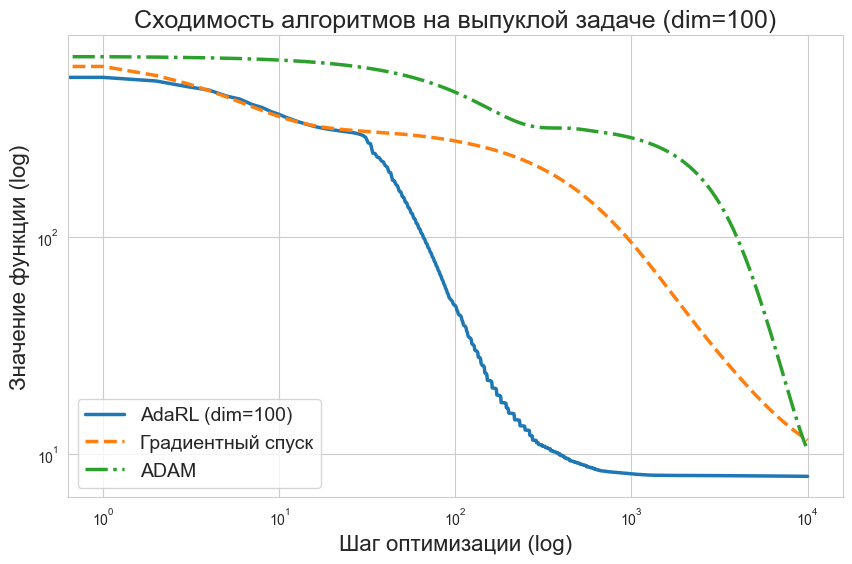

In [2]:
for dim in available_dims:
    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir)

    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов на выпуклой задаче (dim={dim})")
    

In [5]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    stats = exps.plot_iterations_distribution_vs_standart(sample_count=sample_count, env_config=env_config, model_dir=model_dir)

    stats['mean_norm'] = np.round(stats['mean'] / max_iterations, 3)

    display(stats)

Distribution of iterations number on 2-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=2),117.52,9945.37,99.73,23.0,406.0,383.0,0.012
Градиентный спуск,4435.60,14106660.00,3755.88,311.0,10001.0,9690.0,0.444
ADAM,9387.40,2070468.88,1438.91,3489.0,10001.0,6512.0,0.939


Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=5),785.00,3557359.12,1886.10,164.0,9999.0,9835.0,0.078
Градиентный спуск,9889.28,189561.40,435.39,7846.0,10001.0,2155.0,0.989
ADAM,9933.36,109804.07,331.37,8310.0,10001.0,1691.0,0.993


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=10),8250.44,11167579.05,3341.79,573.0,9999.0,9426.0,0.825
Градиентный спуск,10001.00,0.00,0.00,10001.0,10001.0,0.0,1.000
ADAM,10001.00,0.00,0.00,10001.0,10001.0,0.0,1.000


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
Градиентный спуск,10001.0,0.0,0.0,10001.0,10001.0,0.0,1.0
ADAM,10001.0,0.0,0.0,10001.0,10001.0,0.0,1.0


### 2. Convergence for different function scale parameter

For fixed dim = 5, let's compare the convergence of standard methods and adaptive LR on different scale parameters.

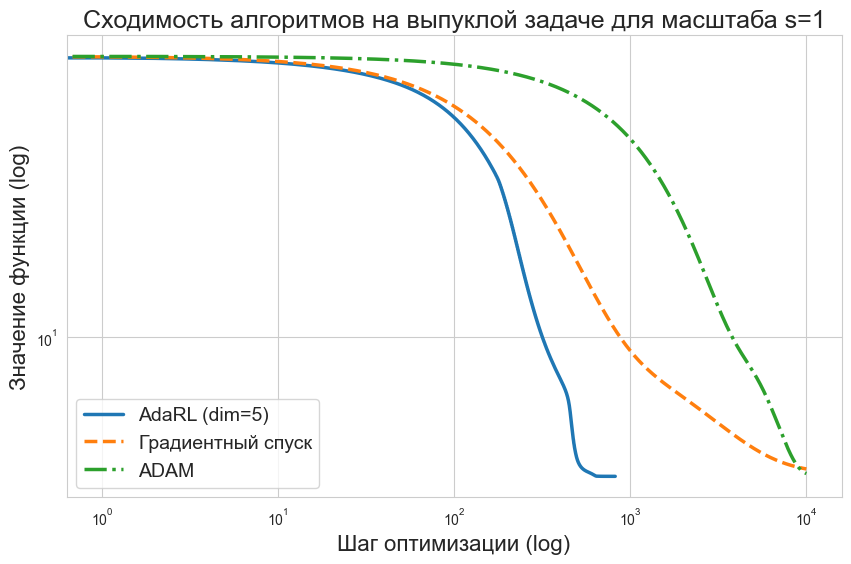

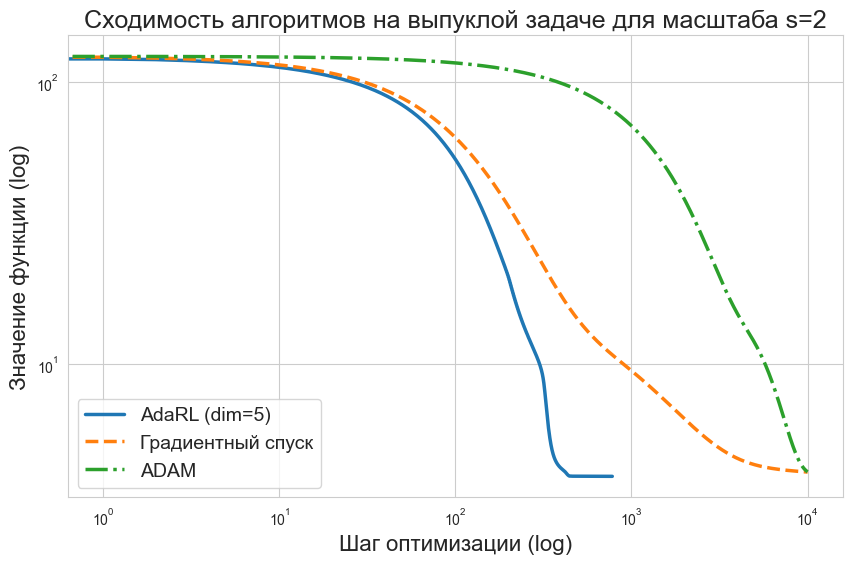

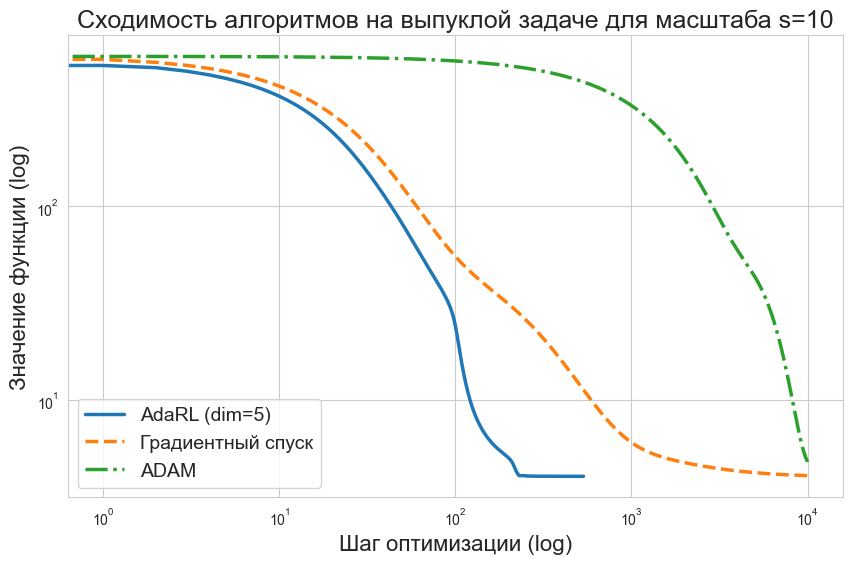

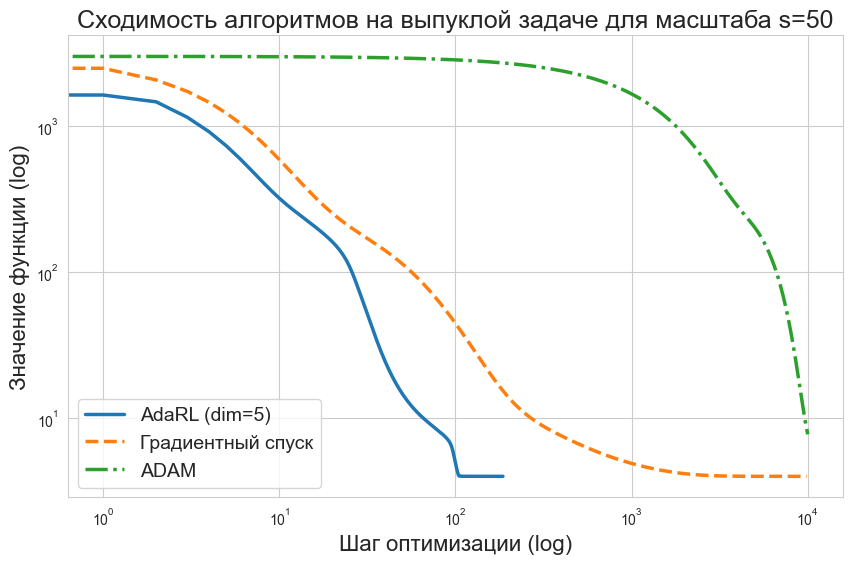

In [3]:
scales = [1, 2, 10, 50]

fixed_dim = 5

for scale in scales:
    stats = f"../models/{fixed_dim}d_convex_vec_normalize.pkl"
    model = f"../models/{fixed_dim}d_convex"
    
    env_kwargs = {**base_env_kwargs, "scale": scale}
    env_config = exps.get_env_config(seed, fixed_dim, max_iterations, env_id, env_kwargs=env_kwargs)

    env_config = exps.get_env_config(seed, fixed_dim, max_iterations, env_id, env_kwargs=env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL (dim=5)", env_config=env_config, model_dir=model_dir)
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, fixed_dim, title=f"Сходимость алгоритмов на выпуклой задаче для масштаба s={scale}")

### 3. Early stop by metric vs the usual model

Let's compare the usual model against an early stop in terms of the average number of steps.

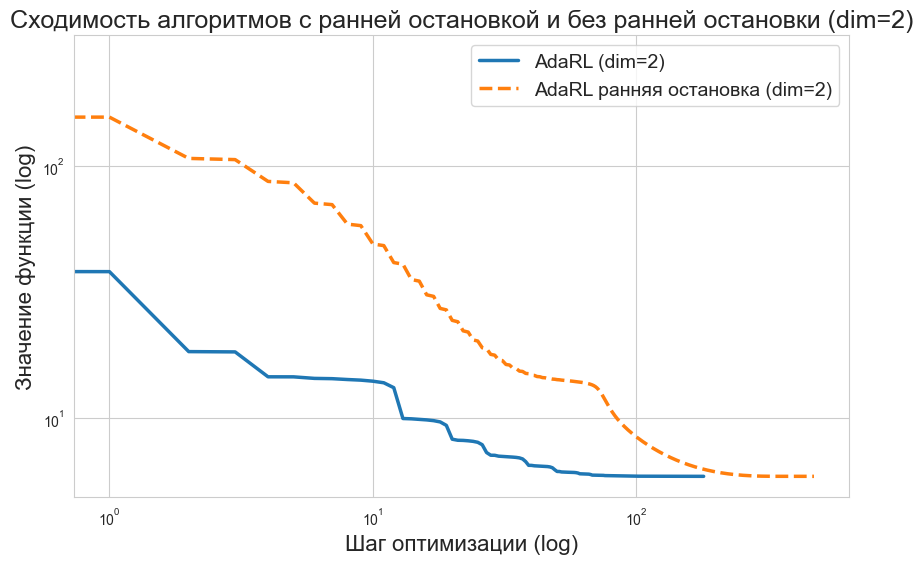

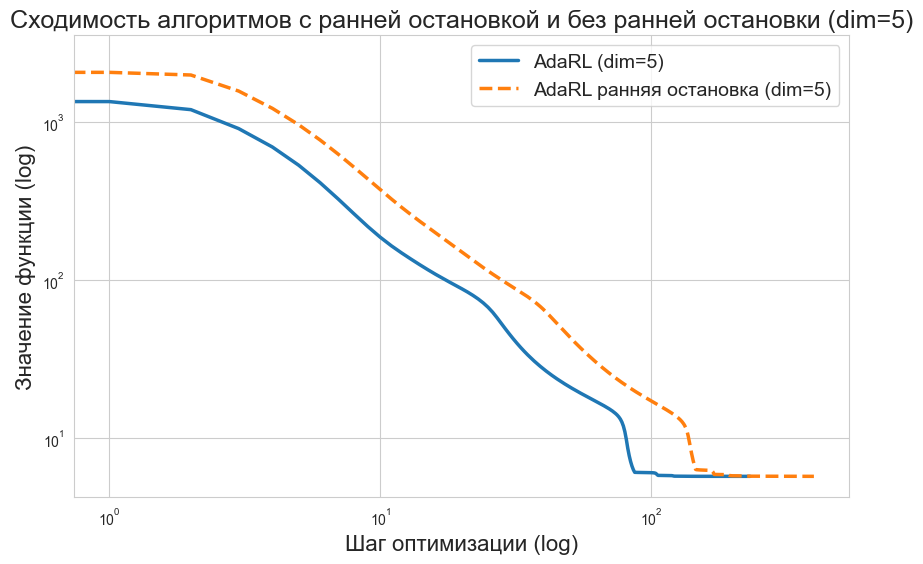

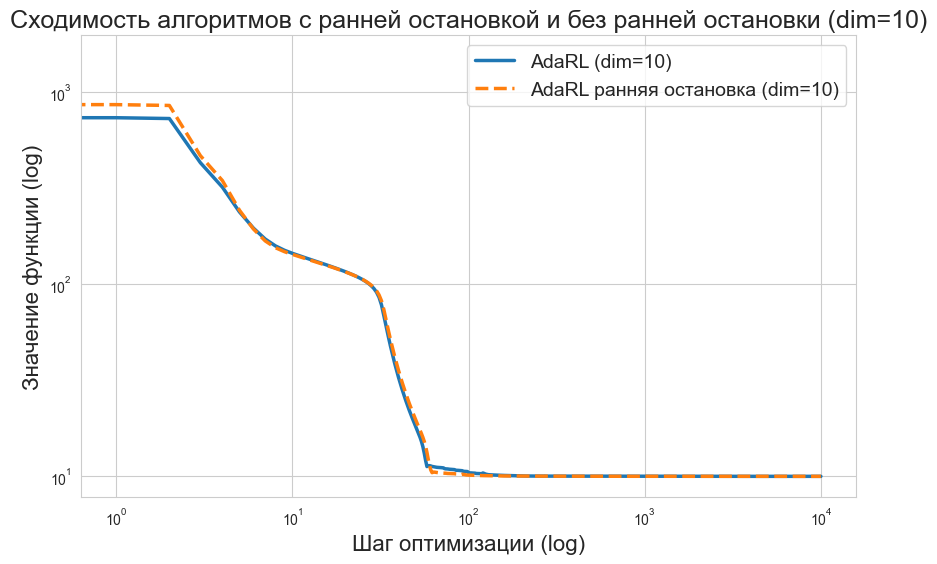

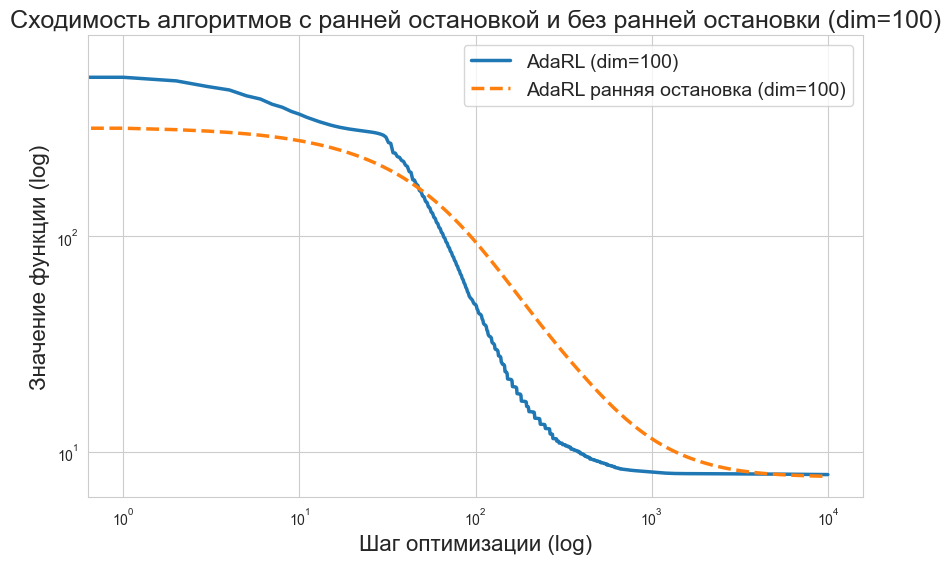

In [4]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_defualt = exps.get_model_dir(stats_defualt, model_defualt)
    
    stats_early_stopping = f"../models/{dim}d_convex_best/best_vec_normalize.pkl"
    model_early_stopping = f"../models/{dim}d_convex_best/best_model"
    model_dir_early_stopping = exps.get_model_dir(stats_early_stopping, model_early_stopping)

    result_default, x0, function = exps.optimize_exp_rl(method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir_defualt)
    result_early_stopping, x0, function = exps.optimize_exp_rl(method=f"AdaRL ранняя остановка (dim={dim})", env_config=env_config, model_dir=model_dir_early_stopping)

    result = result_default | result_early_stopping

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов с ранней остановкой и без ранней остановки (dim={dim})")
    

In [8]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations stop by metric vs the usual model (dim = {dim})")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_defualt = exps.get_model_dir(stats_defualt, model_defualt)
    
    stats_early_stopping = f"../models/{dim}d_convex_best/best_vec_normalize.pkl"
    model_early_stopping = f"../models/{dim}d_convex_best/best_model"
    model_dir_early_stopping = exps.get_model_dir(stats_early_stopping, model_early_stopping)

    models = {
        f"AdaRL (dim={dim})" : model_dir_defualt,
        f"AdaRL ранняя остановка (dim={dim})" : model_dir_early_stopping
    }

    stats = exps.plot_iterations_distribution(sample_count=sample_count, env_config=env_config, models=models)

    stats['mean_norm'] = np.round(stats['mean'] / max_iterations, 3)

    display(stats)

Distribution of iterations stop by metric vs the usual model (dim = 2)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=2),181.0,0.0,0.0,181.0,181.0,0.0,0.018
AdaRL ранняя остановка (dim=2),473.0,0.0,0.0,473.0,473.0,0.0,0.047


Distribution of iterations stop by metric vs the usual model (dim = 5)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=5),233.0,0.0,0.0,233.0,233.0,0.0,0.023
AdaRL ранняя остановка (dim=5),400.0,0.0,0.0,400.0,400.0,0.0,0.040


Distribution of iterations stop by metric vs the usual model (dim = 10)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=10),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
AdaRL ранняя остановка (dim=10),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0


Distribution of iterations stop by metric vs the usual model (dim = 100)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
AdaRL ранняя остановка (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0


### 4. Random dimension model vs. fixed dimension model

Let's compare a model trained on an environment with a random dimension against a model trained on an environment with a fixed dimension

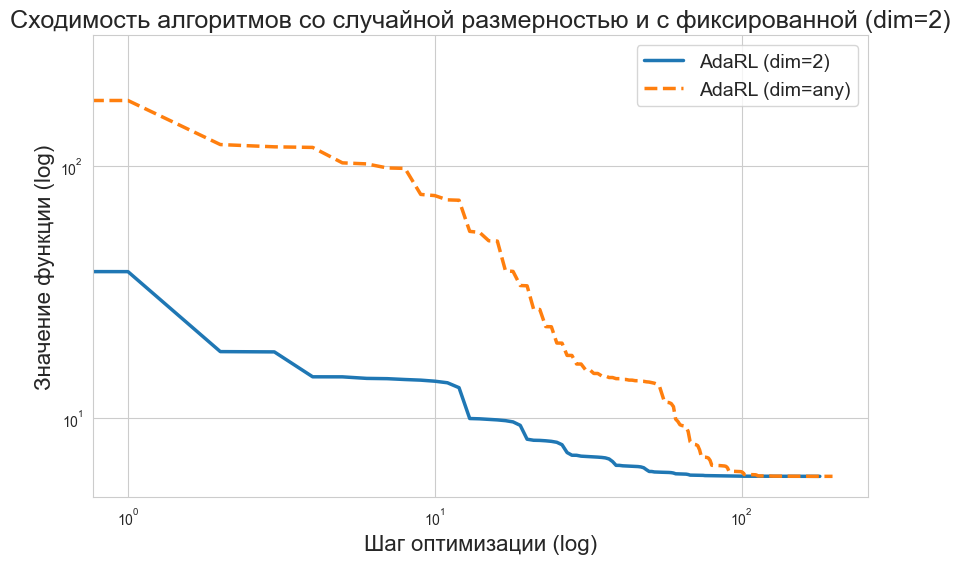

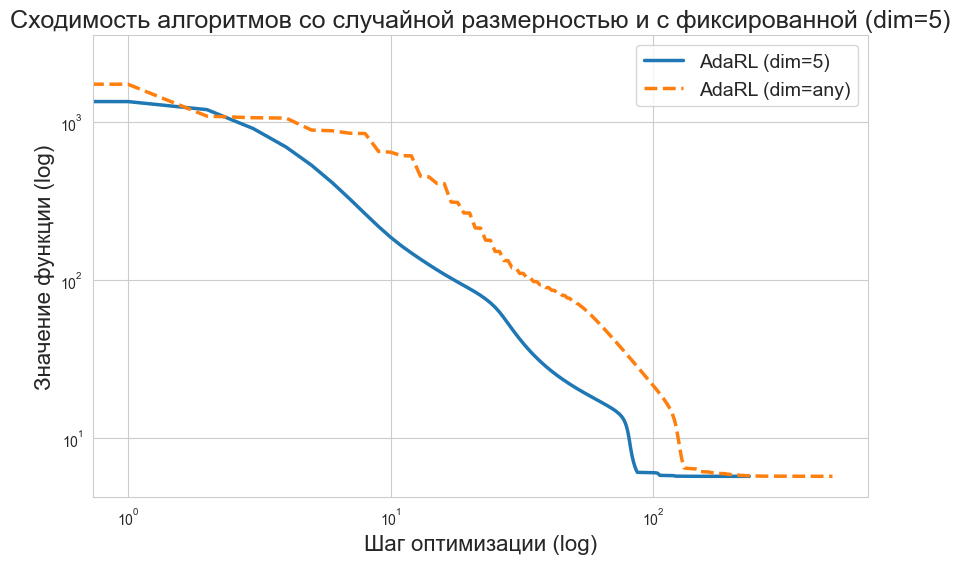

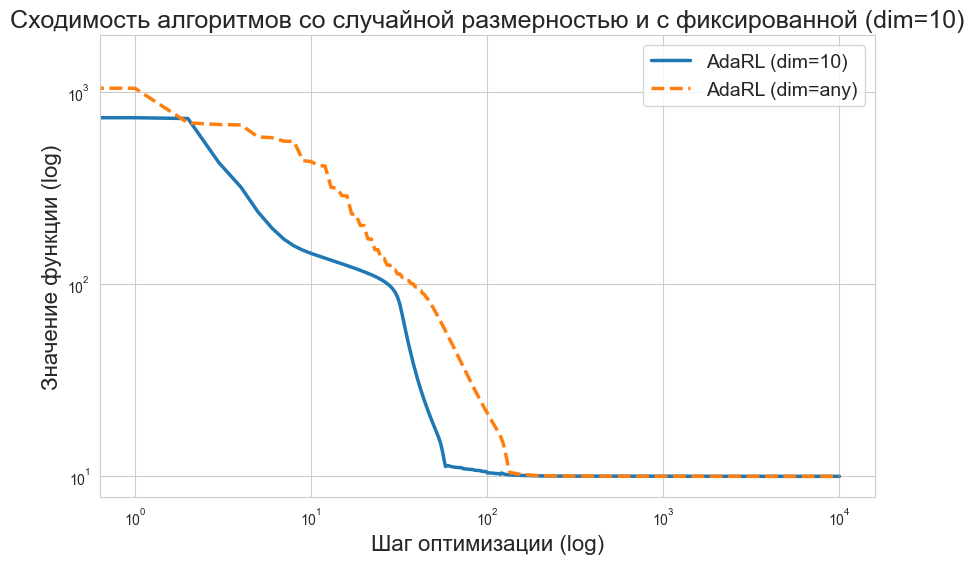

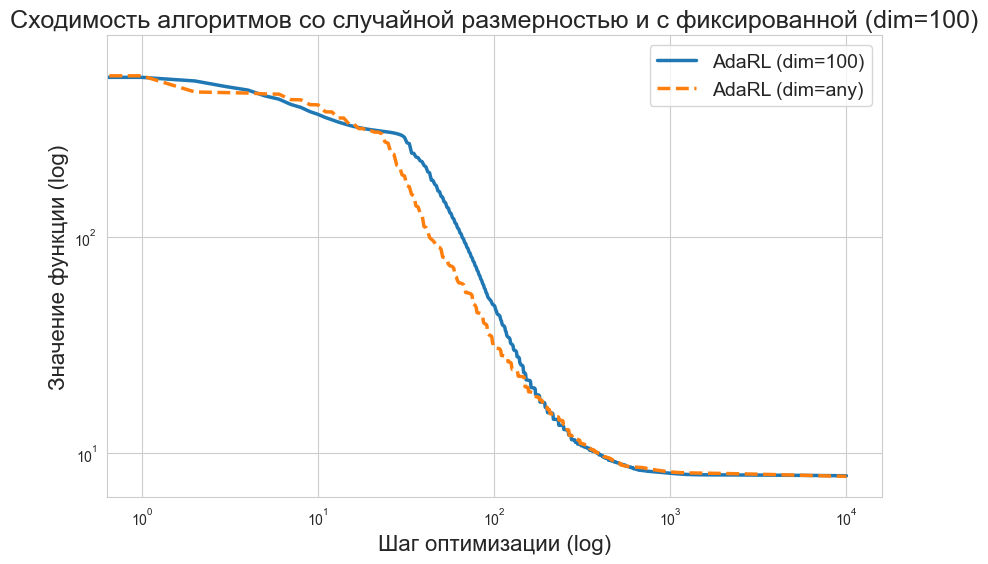

In [5]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_defualt = exps.get_model_dir(stats_defualt, model_defualt)
    
    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    result_default, x0, function = exps.optimize_exp_rl(method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir_defualt)
    result_any_d, x0, function = exps.optimize_exp_rl(method="AdaRL (dim=any)", env_config=env_config, model_dir=model_dir_any_dim)

    result = result_default | result_any_d

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов со случайной размерностью и с фиксированной (dim={dim})")
    

In [10]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations number random dim vs fixed dim = {dim}")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    
    stats_defualt = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_defualt = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_defualt, model_defualt)

    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    models = {
        f"Adaptive LR (dim={dim})" : model_dir_default,
        "Adaptive LR (dim=random)" : model_dir_any_dim
    }

    stats = exps.plot_iterations_distribution(sample_count=sample_count, env_config=env_config, models=models)

    stats['mean_norm'] = np.round(stats['mean'] / max_iterations, 3)

    display(stats)

Distribution of iterations number random dim vs fixed dim = 2


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=2),181.0,0.0,0.0,181.0,181.0,0.0,0.018
Adaptive LR (dim=random),199.0,0.0,0.0,199.0,199.0,0.0,0.020


Distribution of iterations number random dim vs fixed dim = 5


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=5),233.0,0.0,0.0,233.0,233.0,0.0,0.023
Adaptive LR (dim=random),482.0,0.0,0.0,482.0,482.0,0.0,0.048


Distribution of iterations number random dim vs fixed dim = 10


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=10),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
Adaptive LR (dim=random),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0


Distribution of iterations number random dim vs fixed dim = 100


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
Adaptive LR (dim=random),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0


### 5. Adding a time penalty on the convergence of a random dimension model

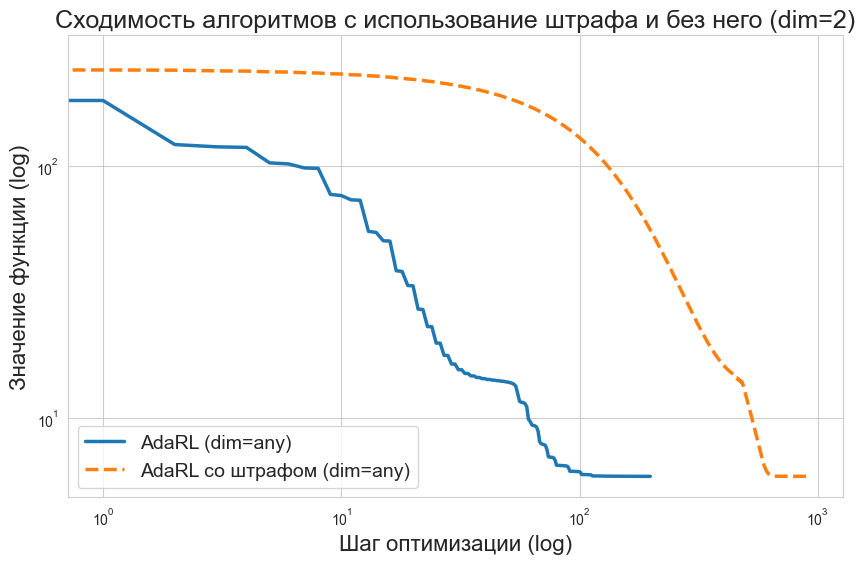

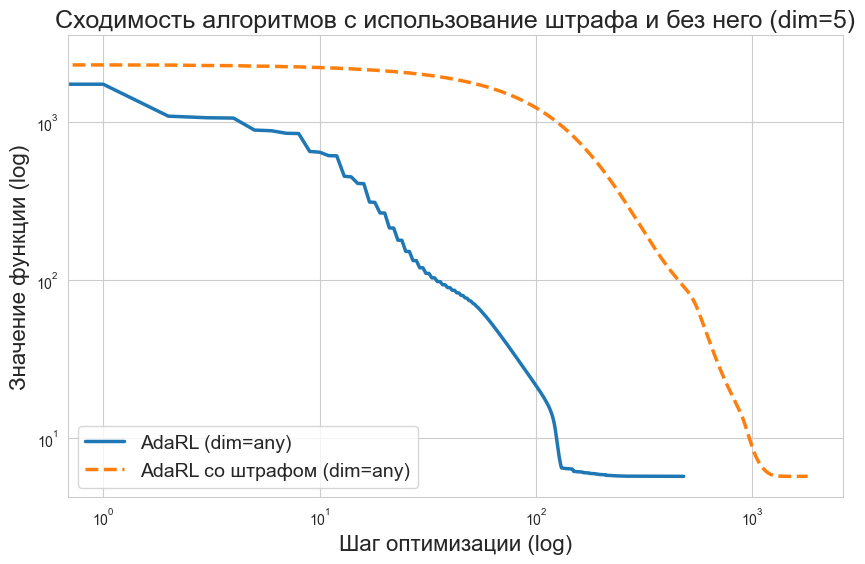

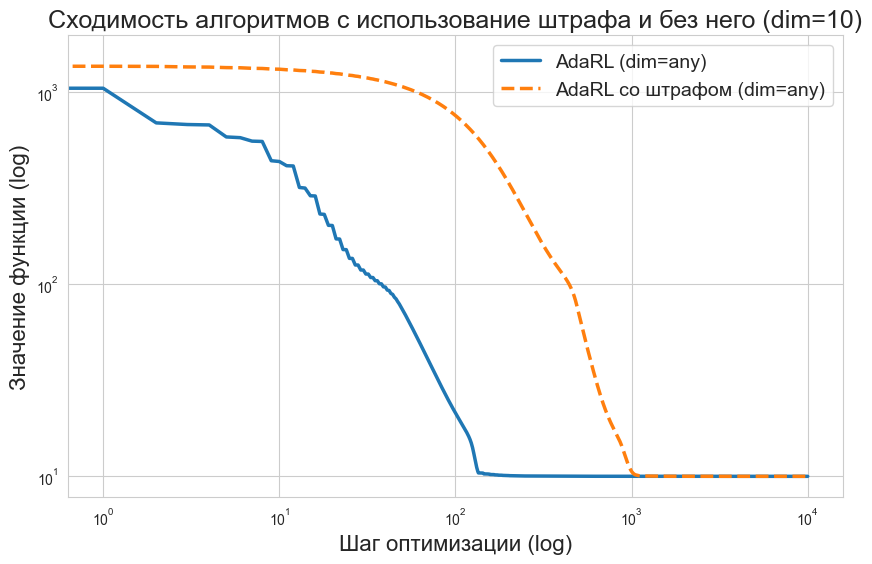

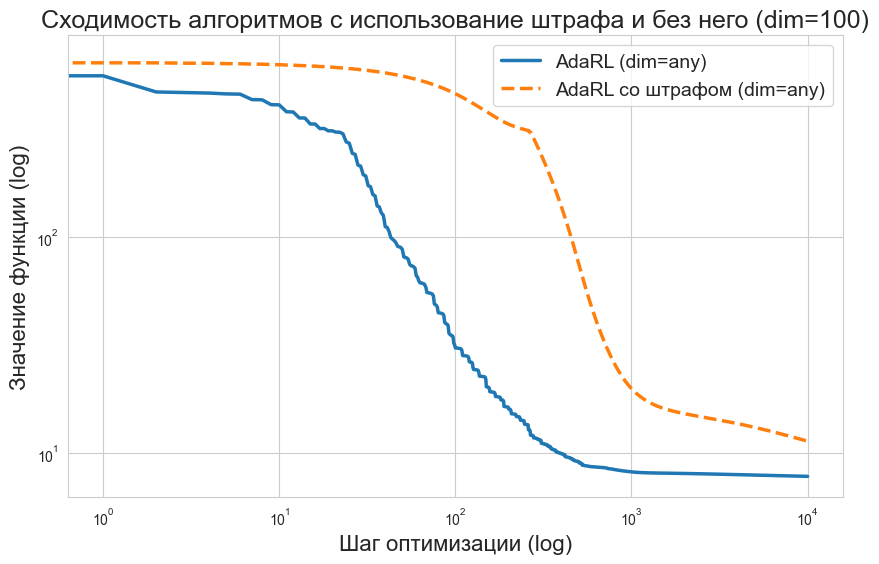

In [7]:
for dim in available_dims:
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_time_penalty = f"../models/time_penalty_anyd_convex_vec_normalize.pkl"
    model_time_penalty = f"../models/time_penalty_anyd_convex"
    model_dir_time_penalty = exps.get_model_dir(stats_time_penalty, model_time_penalty)

    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    result_time_penalty, x0, function = exps.optimize_exp_rl(method=f"AdaRL со штрафом (dim=any)", env_config=env_config, model_dir=model_dir_time_penalty)
    result_any_d, x0, function = exps.optimize_exp_rl(method="AdaRL (dim=any)", env_config=env_config, model_dir=model_dir_any_dim)

    result = result_any_d | result_time_penalty  

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов с использование штрафа и без него (dim={dim})")
    

In [12]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations with time penalty and usual model {dim}")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    
    stats_time_penalty = f"../models/time_penalty_anyd_convex_vec_normalize.pkl"
    model_time_penalty = f"../models/time_penalty_anyd_convex"
    model_dir_time_penalty = exps.get_model_dir(stats_time_penalty, model_time_penalty)

    stats_any_dim = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim, model_any_dim)

    models = {
        f"AdaRL со штрафом (dim=any)" : model_dir_time_penalty,
        "AdaRL (dim=any)" : model_dir_any_dim
    }

    stats = exps.plot_iterations_distribution(sample_count=sample_count, env_config=env_config, models=models)

    stats['mean_norm'] = np.round(stats['mean'] / max_iterations, 3)

    display(stats)

Distribution of iterations with time penalty and usual model 2


,mean,variance,std,min,max,range,mean_norm
AdaRL со штрафом (dim=any),907.0,0.0,0.0,907.0,907.0,0.0,0.091
AdaRL (dim=any),199.0,0.0,0.0,199.0,199.0,0.0,0.020


Distribution of iterations with time penalty and usual model 5


,mean,variance,std,min,max,range,mean_norm
AdaRL со штрафом (dim=any),1801.0,0.0,0.0,1801.0,1801.0,0.0,0.180
AdaRL (dim=any),482.0,0.0,0.0,482.0,482.0,0.0,0.048


Distribution of iterations with time penalty and usual model 10


,mean,variance,std,min,max,range,mean_norm
AdaRL со штрафом (dim=any),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
AdaRL (dim=any),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0


Distribution of iterations with time penalty and usual model 100


,mean,variance,std,min,max,range,mean_norm
AdaRL со штрафом (dim=any),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
AdaRL (dim=any),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
